# Solution - Exercice 5 : Word2Vec et Embeddings

## Imports et données

In [ ]:
from gensim.models import Word2Vec
from gensim.models.phrases import Phrases, Phraser
from sklearn.manifold import TSNE
from nltk.tokenize import sent_tokenize, word_tokenize
import nltk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('french'))

corpus = [
    "Le machine learning est une branche de l'intelligence artificielle",
    "L'intelligence artificielle révolutionne les technologies modernes",
    "Les réseaux de neurones sont au cœur du deep learning",
    "Le deep learning utilise les réseaux de neurones profonds",
    "Les algorithmes d'apprentissage automatique traitent les données",
    "L'apprentissage profond demande beaucoup de données et de puissance calcul",
    "Les embeddings denses représentent les mots dans un espace continu",
    "La similarité cosinus mesure la proximité entre vecteurs",
    "Les modèles pré-entraînés accélèrent le développement",
    "Word2Vec génère des embeddings en capturant le contexte sémantique"
]

def tokenize_text(text):
    # Séparer les apostrophes
    text = re.sub(r"([dl])'", " ", text)  # d'apprentissage -> d' apprentissage
    # Tokenisation normale
    tokens = word_tokenize(text.lower())

    tokens = [token for token in tokens if token.isalnum() and token not in stop_words]
    return tokens

sentences = [tokenize_text(doc) for doc in corpus]

print(f"Corpus: {len(corpus)} phrases")
print(f"Tokens: {sum(len(s) for s in sentences)} tokens totals")

# Créer des bigrammes (n-grams)
# Phrases détecte automatiquement les bigrammes fréquents
phrases = Phrases(sentences, min_count=1, threshold=1)
bigram = Phraser(phrases)

# Appliquer les bigrammes
sentences_with_ngrams = [bigram[sent] for sent in sentences]

print(f"  {' '.join(sentences_with_ngrams[0])}")

for sent in sentences_with_ngrams:
    bigrams_found = [word for word in sent if '_' in word]
    if bigrams_found:
        print(f"  {bigrams_found}")

Corpus: 10 phrases
Tokens: 52 tokens totals
  machine learning branche intelligence artificielle
  ['réseaux_neurones', 'deep_learning']
  ['deep_learning', 'réseaux_neurones']


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Administrateur\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrateur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Tâche 2 : Entraînement Skip-gram

In [38]:
model_skipgram = Word2Vec(
    sentences_with_ngrams,
    sg=1,  # Skip-gram
    vector_size=100,
    window=5,
    min_count=1,
    seed=42
)

print(f"Taille vocabulaire: {len(model_skipgram.wv)}")
print(f"Dimension embedding: {model_skipgram.vector_size}")

# Embedding d'un mot
embedding = model_skipgram.wv['apprentissage']
print(f"\nEmbedding de 'apprentissage': {embedding[:10]}... (shape: {embedding.shape})")

Taille vocabulaire: 43
Dimension embedding: 100

Embedding de 'apprentissage': [-0.00268576 -0.00737985 -0.00971159 -0.00122095  0.00402225 -0.00393885
  0.00720913 -0.00261597  0.00801794 -0.0052826 ]... (shape: (100,))


## Tâche 3 : Entraînement CBOW et comparaison

In [39]:
model_cbow = Word2Vec(
    sentences_with_ngrams,
    sg=0,  # CBOW
    vector_size=100,
    window=5,
    min_count=1,
    seed=42
)

print(f"Skip-gram vocab: {len(model_skipgram.wv)}")
print(f"CBOW vocab: {len(model_cbow.wv)}")

# Comparer les embeddings
word = 'apprentissage'
emb_sg = model_skipgram.wv[word]
emb_cbow = model_cbow.wv[word]
similarity = np.dot(emb_sg, emb_cbow) / (np.linalg.norm(emb_sg) * np.linalg.norm(emb_cbow))

print(f"\nSimilarité embeddings '{word}': {similarity:.4f}")

Skip-gram vocab: 43
CBOW vocab: 43

Similarité embeddings 'apprentissage': 1.0000


## Tâche 4 : Similarité et opérations sémantiques

In [40]:
model = model_skipgram 


print("MÉTHODE 1: Moyenne des embeddings (pour mots séparés)")

pairs = [
    ('machine learning', 'apprentissage automatique'),
    ('deep learning', 'réseaux neurones'),
    ('apprentissage', 'données')
]

for phrase1, phrase2 in pairs:
    words1 = phrase1.split()
    words2 = phrase2.split()
    
    # Calculer les embeddings moyens pour les phrases
    emb1_list = [model.wv[w] for w in words1 if w in model.wv]
    emb2_list = [model.wv[w] for w in words2 if w in model.wv]
    
    if emb1_list and emb2_list:
        emb1 = np.mean(emb1_list, axis=0)
        emb2 = np.mean(emb2_list, axis=0)

        sim = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
        print(f"Similarité('{phrase1}', '{phrase2}'): {sim:.4f}")
    else:
        print(f"Similarité('{phrase1}', '{phrase2}'): Mots manquants dans vocabulaire")

# Utiliser les bigrammes directement
bigram_pairs = [
    ('machine_learning', 'apprentissage_automatique'),
    ('deep_learning', 'réseaux_neurones'),
    ('apprentissage', 'données')
]

for phrase1, phrase2 in bigram_pairs:
    if phrase1 in model.wv and phrase2 in model.wv:
        sim = model.wv.similarity(phrase1, phrase2)
        print(f"Similarité('{phrase1}', '{phrase2}'): {sim:.4f}")
    else:
        print(f"Similarité('{phrase1}', '{phrase2}'): Bigrammes non disponibles")

# 2. Mots les plus similaires à "intelligence artificielle"
for word in ['intelligence', 'artificielle']:
    if word in model.wv:
        print(f"\nMots similaires à '{word}':")
        similars = model.wv.most_similar(word, topn=5)
        for w, score in similars:
            print(f"  {w}: {score:.4f}")

# Si le bigramme existe
if 'intelligence_artificielle' in model.wv:
    print(f"\nMots similaires à 'intelligence_artificielle' (bigramme):")
    similars = model.wv.most_similar('intelligence_artificielle', topn=5)
    for w, score in similars:
        print(f"  {w}: {score:.4f}")

# 3. Mots les plus dissimilaires

word_ref = 'intelligence'
if word_ref in model.wv:
    # Tous les mots avec leur similarité
    all_words = model.wv.index_to_key
    similarities = [(w, model.wv.similarity(word_ref, w)) for w in all_words if w != word_ref]
    # Trier par similarité croissante
    similarities.sort(key=lambda x: x[1])
    
    print(f"Mots les plus dissimilaires de '{word_ref}':")
    for w, score in similarities[:5]:
        print(f"  {w}: {score:.4f}")

# 4. Analogies Word2Vec
print("Test: 'intelligence' - 'artificielle' + 'machine' ?")

try:
    if all(w in model.wv for w in ['intelligence', 'artificielle', 'machine']):
        result = model.wv.most_similar(
            positive=['intelligence', 'machine'],
            negative=['artificielle'],
            topn=5
        )
        print("\nRésultats:")
        for word, score in result:
            print(f"  {word}: {score:.4f}")
except Exception as e:
    print(f"Erreur: {e}")


MÉTHODE 1: Moyenne des embeddings (pour mots séparés)
Similarité('machine learning', 'apprentissage automatique'): -0.0276
Similarité('deep learning', 'réseaux neurones'): Mots manquants dans vocabulaire
Similarité('apprentissage', 'données'): -0.0174
Similarité('machine_learning', 'apprentissage_automatique'): Bigrammes non disponibles
Similarité('deep_learning', 'réseaux_neurones'): 0.1044
Similarité('apprentissage', 'données'): -0.0174

Mots similaires à 'intelligence':
  données: 0.1594
  modernes: 0.1585
  mots: 0.1580
  learning: 0.1278
  utilise: 0.1136

Mots similaires à 'artificielle':
  beaucoup: 0.2708
  apprentissage: 0.0939
  réseaux_neurones: 0.0893
  utilise: 0.0693
  calcul: 0.0672
Mots les plus dissimilaires de 'intelligence':
  denses: -0.2105
  calcul: -0.1958
  artificielle: -0.1085
  cosinus: -0.0901
  sémantique: -0.0775
Test: 'intelligence' - 'artificielle' + 'machine' ?

Résultats:
  mots: 0.2007
  learning: 0.1991
  algorithmes: 0.1675
  génère: 0.1656
  dévelo

## Tâche 5 : Visualisation 2D avec t-SNE

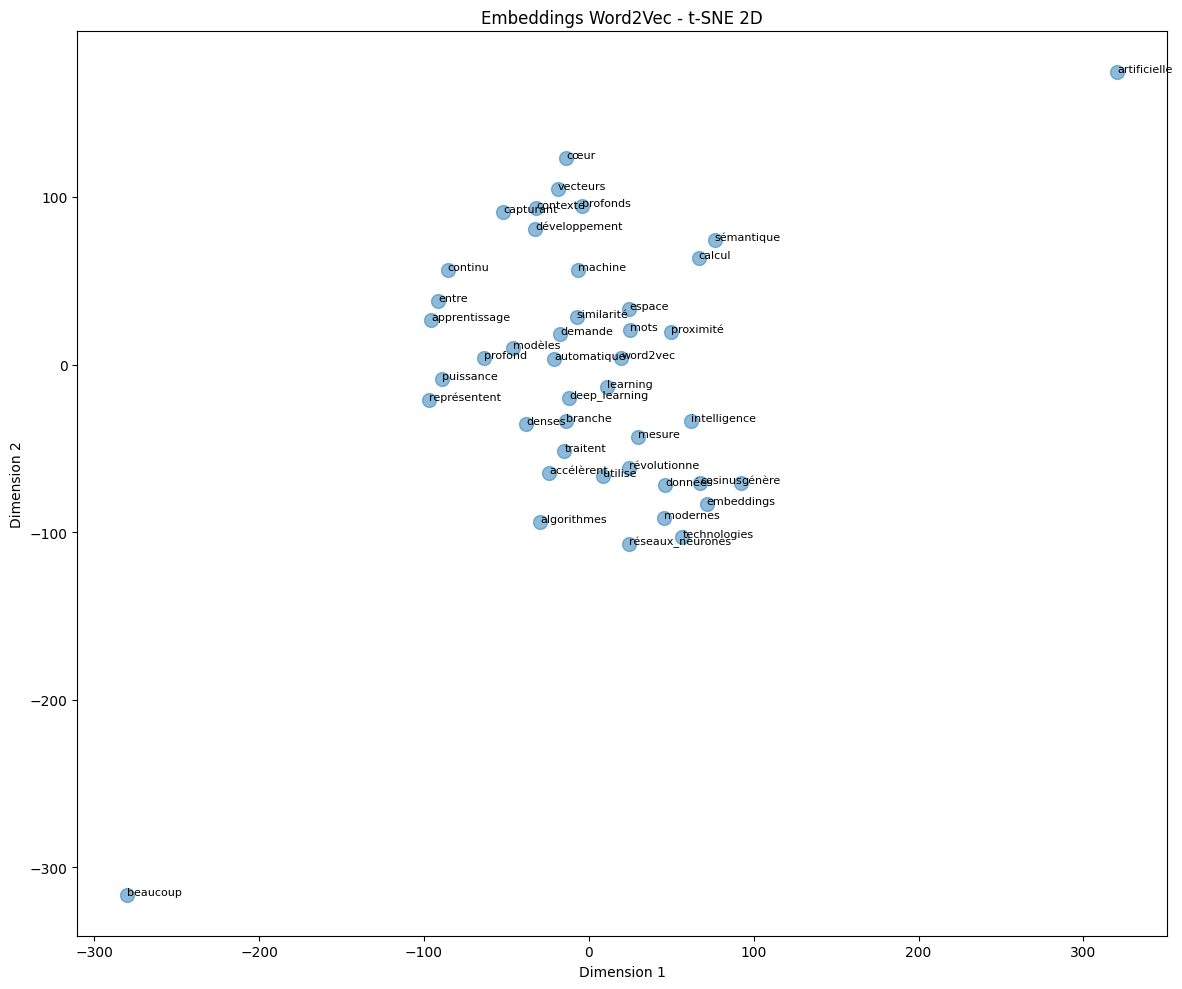

In [41]:
# Réduire avec t-SNE
vectors = model.wv.vectors
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
vectors_2d = tsne.fit_transform(vectors)

# Visualiser
plt.figure(figsize=(12, 10))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.5, s=100)

# Annoter les mots
for i, word in enumerate(model.wv.index_to_key):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), fontsize=8)

plt.title('Embeddings Word2Vec - t-SNE 2D')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.tight_layout()
plt.show()


## Tâche 6 : Embeddings de documents

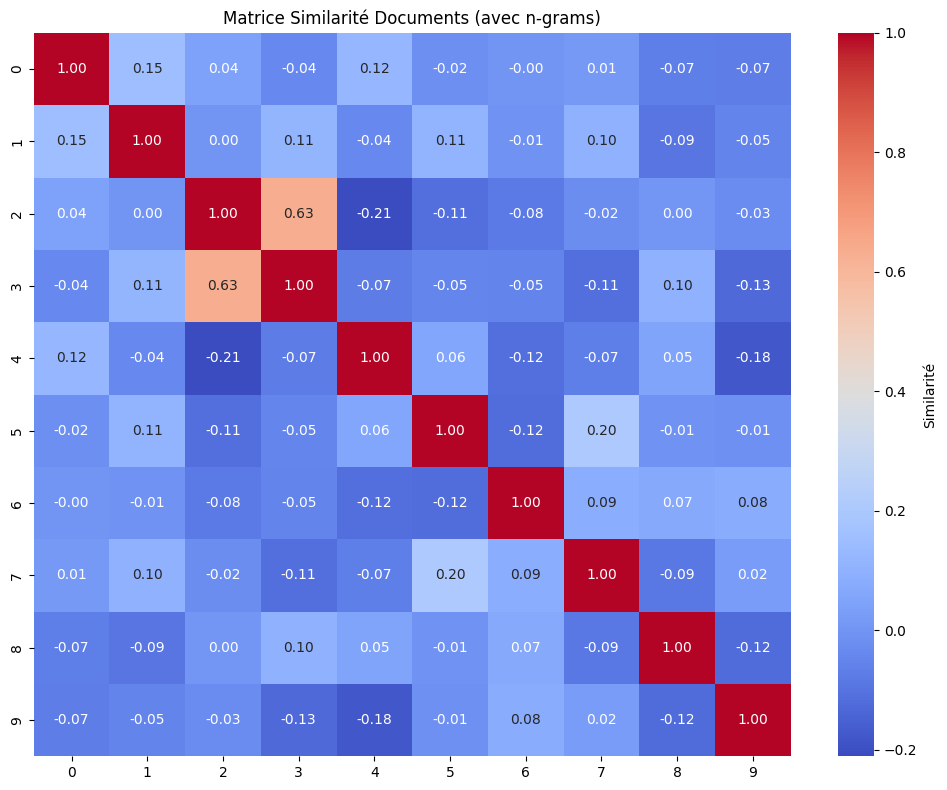

Paires documents les plus similaires:


In [42]:
def get_document_embedding(tokens, model):
    valid_tokens = [t for t in tokens if t in model.wv]
    if not valid_tokens:
        return np.zeros(model.vector_size)
    return np.mean([model.wv[t] for t in valid_tokens], axis=0)

# Embeddings de documents (avec n-grams)
doc_embeddings = [get_document_embedding(sent, model) for sent in sentences_with_ngrams]
doc_embeddings = np.array(doc_embeddings)

from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(doc_embeddings)

# Visualiser
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'label': 'Similarité'})
plt.title('Matrice Similarité Documents (avec n-grams)')
plt.tight_layout()
plt.show()

# Paires les plus similaires
print("Paires documents les plus similaires:")
for i in range(len(similarity_matrix)):
    for j in range(i+1, len(similarity_matrix)):
        if similarity_matrix[i, j] > 0.7:
            print(f"Doc {i} - Doc {j}: {similarity_matrix[i, j]:.3f}")

## Tâche 7 : Comparaison Word2Vec vs TF-IDF

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF (avec n-grams maintenant)
tfidf = TfidfVectorizer(max_features=100)
X_tfidf = tfidf.fit_transform([' '.join(s) for s in sentences_with_ngrams])

# Similarité avec TF-IDF
tfidf_similarity = cosine_similarity(X_tfidf)

# Exemple: similarité entre doc 0 et doc 1
idx1, idx2 = 0, 1
sim_word2vec = similarity_matrix[idx1, idx2]
sim_tfidf = tfidf_similarity[idx1, idx2]

print(f"\nDoc {idx1} vs Doc {idx2}:")
print(f"Word2Vec similarity (avec n-grams): {sim_word2vec:.4f}")
print(f"TF-IDF similarity (avec n-grams): {sim_tfidf:.4f}")


Doc 0 vs Doc 1:
Word2Vec similarity (avec n-grams): 0.1499
TF-IDF similarity (avec n-grams): 0.1724


## BONUS 1 : Impact de vector_size sur la qualité

In [44]:
vector_sizes = [50, 100, 300]
models_comparison = {}

for size in vector_sizes:
    model_temp = Word2Vec(
        sentences,
        sg=1,
        vector_size=size,
        window=5,
        min_count=1,
        seed=42
    )
    models_comparison[size] = model_temp
    
    if 'apprentissage' in model_temp.wv and 'automatique' in model_temp.wv:
        sim = model_temp.wv.similarity('apprentissage', 'automatique')
        print(f"\nVector size {size}:")
        print(f"  Similarité ('apprentissage', 'automatique'): {sim:.4f}")
        print(f"  Mémoire (approximatif): {len(model_temp.wv) * size * 4 / 1024:.2f} KB")



Vector size 50:
  Similarité ('apprentissage', 'automatique'): -0.0404
  Mémoire (approximatif): 8.59 KB

Vector size 100:
  Similarité ('apprentissage', 'automatique'): -0.0574
  Mémoire (approximatif): 17.19 KB

Vector size 300:
  Similarité ('apprentissage', 'automatique'): 0.1105
  Mémoire (approximatif): 51.56 KB


## BONUS 2 : Utiliser des embeddings pré-entraînés (FastText)

In [45]:
from gensim.models import FastText


model_fasttext = FastText(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    seed=42
)

print(f"Vocabulaire FastText: {len(model_fasttext.wv)}")

# Avantage: peut gérer les mots hors vocabulaire (OOV)
# Exemple avec un mot qui n'existe pas dans le corpus
word_oov = "apprentissages" 
if word_oov not in model.wv:
    print(f"\n'{word_oov}' n'existe pas dans Word2Vec")
else:
    print(f"\n'{word_oov}' existe dans Word2Vec")

# FastText peut générer un embedding même pour un mot non vu
try:
    embedding_oov = model_fasttext.wv[word_oov]
    print(f"FastText génère un embedding pour '{word_oov}': shape {embedding_oov.shape}")
except KeyError:
    print(f"FastText ne peut pas générer d'embedding pour '{word_oov}'")

# Comparaison similarité
word_test = 'apprentissage'
if word_test in model.wv and word_test in model_fasttext.wv:
    sim_w2v = model.wv.similarity('apprentissage', 'données')
    sim_ft = model_fasttext.wv.similarity('apprentissage', 'données')
    print(f"\nSimilarité ('apprentissage', 'données'):")
    print(f"  Word2Vec: {sim_w2v:.4f}")
    print(f"  FastText: {sim_ft:.4f}")

Vocabulaire FastText: 44

'apprentissages' n'existe pas dans Word2Vec
FastText génère un embedding pour 'apprentissages': shape (100,)

Similarité ('apprentissage', 'données'):
  Word2Vec: -0.0174
  FastText: -0.0914


## BONUS 3 : Entraînement sur un corpus plus grand

In [46]:
extended_corpus = corpus + [
    "Python est un langage de programmation populaire pour le machine learning",
    "Les bibliothèques comme TensorFlow et PyTorch facilitent le deep learning",
    "La régression linéaire est un algorithme d'apprentissage supervisé simple",
    "Les arbres de décision sont utilisés pour la classification et la régression",
    "Le gradient descent optimise les paramètres des modèles",
    "Les transformers révolutionnent le traitement du langage naturel",
    "BERT et GPT sont des modèles de langage pré-entraînés puissants",
    "L'attention est un mécanisme clé dans les architectures modernes",
    "Les réseaux convolutifs excellent dans le traitement d'images",
    "Le traitement du langage naturel utilise des embeddings de mots",
    "Les données non structurées nécessitent un prétraitement spécifique",
    "La validation croisée évalue la performance des modèles",
    "Le surapprentissage est un problème courant en machine learning",
    "La régularisation aide à prévenir le surapprentissage",
    "Les hyperparamètres doivent être optimisés pour de meilleures performances"
]


extended_sentences = []
for text in extended_corpus:
    tokens = word_tokenize(text.lower())
    extended_sentences.append(tokens)

print(f"Nombre de phrases: {len(extended_sentences)}")
print(f"Nombre total de tokens: {sum(len(s) for s in extended_sentences)}")


model_large = Word2Vec(
    extended_sentences,
    sg=1,
    vector_size=100,
    window=5,
    min_count=2,
    seed=42
)

print(f"\nVocabulaire: {len(model_large.wv)} mots")

if 'apprentissage' in model_large.wv:
    print("\nMots similaires à 'apprentissage' (corpus étendu):")
    similars = model_large.wv.most_similar('apprentissage', topn=5)
    for word, score in similars:
        print(f"  {word}: {score:.4f}")


Nombre de phrases: 25
Nombre total de tokens: 220

Vocabulaire: 33 mots


## BONUS 4 : Skip-gram manuel (implémentation du contexte personnalisé)

In [47]:
# Implémentation manuelle de la génération de paires (mot central, mot contexte)
def generate_skip_gram_pairs(sentences, window_size=2):
    pairs = []
    
    for sentence in sentences:
        for i, center_word in enumerate(sentence):
            # Contexte gauche et droit
            context_start = max(0, i - window_size)
            context_end = min(len(sentence), i + window_size + 1)
            
            for j in range(context_start, context_end):
                if i != j: 
                    context_word = sentence[j]
                    pairs.append((center_word, context_word))
    
    return pairs

pairs = generate_skip_gram_pairs(sentences[:3], window_size=2)

print(f"Nombre de paires générées (3 premières phrases): {len(pairs)}")
for i, (center, context) in enumerate(pairs[:10]):
    print(f"  {i+1}. ('{center}', '{context}')")

Nombre de paires générées (3 premières phrases): 38
  1. ('machine', 'learning')
  2. ('machine', 'branche')
  3. ('learning', 'machine')
  4. ('learning', 'branche')
  5. ('learning', 'intelligence')
  6. ('branche', 'machine')
  7. ('branche', 'learning')
  8. ('branche', 'intelligence')
  9. ('branche', 'artificielle')
  10. ('intelligence', 'learning')
